### Can we accurately predict Airbnb prices using listing characteristics?

### Which factors are the most important drivers of Airbnb prices?

### Do different neighborhoods have distinct pricing patterns?

In [149]:
# Import packages

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error

pd.set_option('display.max_columns', None)

In [150]:
# Load the dataset (Hawaii)

hawaii_raw = pd.read_csv("Hawaii_listings.csv.gz")
hawaii_raw.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'ca

In [151]:
# Check the dataset
hawaii_raw

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,5269,https://www.airbnb.com/rooms/5269,20250916040722,2025-09-16,city scrape,Upcountry Hospitality in the 'Auwai Suite,"The 'Auwai Suite is a lovely, self-contained a...","We are located on the ""sunny side"" of Waimea, ...",https://a0.muscache.com/pictures/5b52b72f-5a09...,7620,https://www.airbnb.com/users/show/7620,Lea & Pat,2009-02-09,"Waimea, HI","Lea, born and raised on the Island of Hawaii, ...",within an hour,100%,98%,t,https://a0.muscache.com/im/pictures/user/16ac6...,https://a0.muscache.com/im/pictures/user/16ac6...,Island of Hawaiʻi,3.0,6.0,"['email', 'phone']",t,t,Neighborhood highlights,South Kohala,Hawaii,20.027400,-155.702000,Entire rental unit,Entire home/apt,2,1.0,1 bath,1.0,1.0,"[""Smoke alarm"", ""Long term stays allowed"", ""Ex...",$136.00,3,1125,3.0,3.0,1125.0,1125.0,3.0,1125.0,NaN,t,13,35,51,279,2025-09-16,45,7,0,53,6,42,5712.0,2011-05-31,2025-07-15,4.80,4.89,4.60,4.96,4.87,5.00,4.87,119-269-5808-01R,f,3,3,0,0,0.26
1,5387,https://www.airbnb.com/rooms/5387,20250916040722,2025-09-16,city scrape,Hale Koa Studio & 1 Bedroom Units!!,This Wonderful Spacious Studio apt/flat is in ...,IN a Farm belt area with small commercial farm...,https://a0.muscache.com/pictures/1170713/dca6a...,7878,https://www.airbnb.com/users/show/7878,Edward,2009-02-13,"Captain Cook, HI","Kona Hawaii,\n \n Ed is a Farmer/Designer \n\n...",within an hour,100%,100%,f,https://a0.muscache.com/im/pictures/user/b895b...,https://a0.muscache.com/im/pictures/user/b895b...,Kailua/Kona,2.0,2.0,"['email', 'phone']",t,t,Neighborhood highlights,South Kona,Hawaii,19.430810,-155.880690,Entire rental unit,Entire home/apt,2,1.0,1 bath,0.0,2.0,"[""Smoke alarm"", ""Courtyard view"", ""Private bac...",$122.00,5,60,5.0,5.0,1125.0,1125.0,5.0,1125.0,NaN,t,4,18,30,225,2025-09-16,235,11,1,30,14,110,13420.0,2010-02-16,2025-08-21,4.67,4.69,4.43,4.85,4.88,4.75,4.78,TA-163-133-0304-01,t,2,2,0,0,1.24
2,5480,https://www.airbnb.com/rooms/5480,20250916040722,2025-09-16,city scrape,Isle Of You Naturally Farm Retreat,The Best Choice for your Clothing Optional Nud...,We are located on a rural one lane road going ...,https://a0.muscache.com/pictures/75530989/8ed3...,8145,https://www.airbnb.com/users/show/8145,Normand,2009-02-18,"Pāhoa, HI","a decade ago, my husband bailed on the mainla...",NaN,NaN,NaN,f,https://a0.muscache.com/im/users/8145/profile_...,https://a0.muscache.com/im/users/8145/profile_...,Island of Hawaiʻi,3.0,3.0,"['email', 'phone']",t,f,Neighborhood highlights,Puna,Hawaii,19.441490,-154.915270,Private room in cabin,Private room,2,1.0,1 shared bath,1.0,1.0,"[""Host greets you

In [152]:
# Filter uninterested columns

cols_interested = [
    "host_response_time",
    "host_identity_verified",
    "neighbourhood_cleansed",
    "room_type",
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",
    "price",
    "minimum_nights",
    "number_of_reviews",
    "number_of_reviews_ltm",
    "number_of_reviews_l30d",
    "review_scores_rating"      # target variable
]

hawaii = hawaii_raw[cols_interested]
hawaii.info()

<class 'pandas.DataFrame'>
RangeIndex: 33457 entries, 0 to 33456
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   host_response_time      31677 non-null  str    
 1   host_identity_verified  33455 non-null  str    
 2   neighbourhood_cleansed  33457 non-null  str    
 3   room_type               33457 non-null  str    
 4   accommodates            33457 non-null  int64  
 5   bedrooms                33389 non-null  float64
 6   beds                    33421 non-null  float64
 7   bathrooms               33454 non-null  float64
 8   price                   33132 non-null  str    
 9   minimum_nights          33457 non-null  int64  
 10  number_of_reviews       33457 non-null  int64  
 11  number_of_reviews_ltm   33457 non-null  int64  
 12  number_of_reviews_l30d  33457 non-null  int64  
 13  review_scores_rating    26731 non-null  float64
dtypes: float64(4), int64(5), str(5)
memory usage: 3.6

In [153]:
# Data Preprocessing

# Convert data type from Str to Int or Bool
hawaii["host_response_time"].unique()

<StringArray>
[    'within an hour',                  nan,       'within a day',
 'within a few hours', 'a few days or more']
Length: 5, dtype: str

In [154]:
mapping = {
    'within an hour': 1,
    'within a few hours': 2,
    'within a day': 3,
    'a few days or more': 4
}

hawaii['host_response_time'] = hawaii['host_response_time'].map(mapping)

In [155]:
hawaii["host_identity_verified"] = hawaii["host_identity_verified"].map({'t': 1, 'f': 0})

In [156]:
hawaii["price"] = pd.to_numeric(
    hawaii["price"].astype(str).str.replace(r"[\$,]", "", regex=True)
)

In [157]:
hawaii = hawaii.dropna()
hawaii.info()

<class 'pandas.DataFrame'>
Index: 25277 entries, 0 to 33397
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   host_response_time      25277 non-null  float64
 1   host_identity_verified  25277 non-null  float64
 2   neighbourhood_cleansed  25277 non-null  str    
 3   room_type               25277 non-null  str    
 4   accommodates            25277 non-null  int64  
 5   bedrooms                25277 non-null  float64
 6   beds                    25277 non-null  float64
 7   bathrooms               25277 non-null  float64
 8   price                   25277 non-null  float64
 9   minimum_nights          25277 non-null  int64  
 10  number_of_reviews       25277 non-null  int64  
 11  number_of_reviews_ltm   25277 non-null  int64  
 12  number_of_reviews_l30d  25277 non-null  int64  
 13  review_scores_rating    25277 non-null  float64
dtypes: float64(7), int64(5), str(2)
memory usage: 2.9 MB


In [158]:
hawaii.describe()

,host_response_time,host_identity_verified,accommodates,bedrooms,beds,bathrooms,price,minimum_nights,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,review_scores_rating
count,25277.000000,25277.000000,25277.000000,25277.000000,25277.000000,25277.000000,25277.000000,25277.000000,25277.000000,25277.000000,25277.000000,25277.000000
mean,1.197096,0.877794,4.698936,1.565534,2.575662,1.608399,494.122997,5.090675,52.957076,10.947067,0.749416,4.794752
std,0.511541,0.327530,2.316394,1.167095,1.536940,0.889797,2520.399107,13.167623,85.712793,14.874323,1.270641,0.318011
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,9.000000,1.000000,1.000000,0.000000,0.000000,1.000000
25%,1.000000,1.000000,4.000000,1.000000,2.000000,1.000000,149.000000,1.000000,5.000000,1.000000,0.000000,4.730000
50%,1.000000,1.000000,4.000000,1.000000,2.000000,1.000000,217.000000,2.000000,20.000000,5.000000,0.000000,4.890000
75%,1.000000,1.000000,6.000000,2.000000,3.000000,2.000000,350.000000,3.000000,64.000000,16.000000,1.000000,5.000000
max,4.000000,1.000000,16.000000,48.000000,32.000000,13.000000,50123.000000,365.000000,1506.000000,353.000000,29.000000,5.000000


In [159]:
hawaii["neighbourhood_cleansed"].unique()

<StringArray>
[         'South Kohala',            'South Kona',          'Kihei-Makena',
     'North Shore Kauai',                  'Puna',            'North Kona',
               'Lahaina',  'Primary Urban Center',            'Paia-Haiku',
          'Kapaa-Wailua',                   'Ewa',      'North Shore Oahu',
               'Waianae',         'Waimea-Kekaha',               'Molokai',
            'South Hilo',         'East Honolulu',       'Wailuku-Kahului',
            'Koolaupoko',                 'Lihue',           'Koloa-Poipu',
                   'Kau',            'North Hilo',                  'Hana',
             'Koolauloa', 'Makawao-Pukalani-Kula',          'North Kohala',
               'Hamakua',                 'Lanai',          'Central Oahu']
Length: 30, dtype: str

In [ ]:
hawaii["room_type"].unique()

In [160]:
hawaii['bedrooms'].median()

np.float64(1.0)

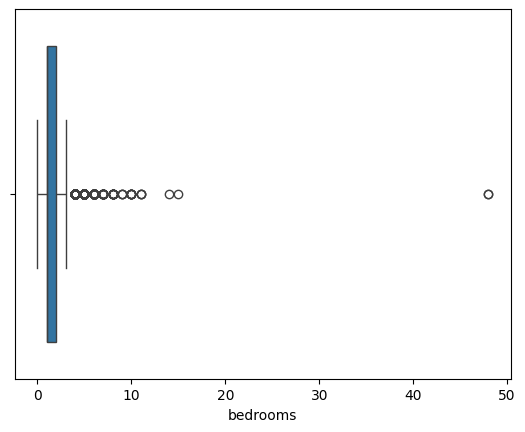

In [161]:
sns.boxplot(x=hawaii["bedrooms"])
plt.show()

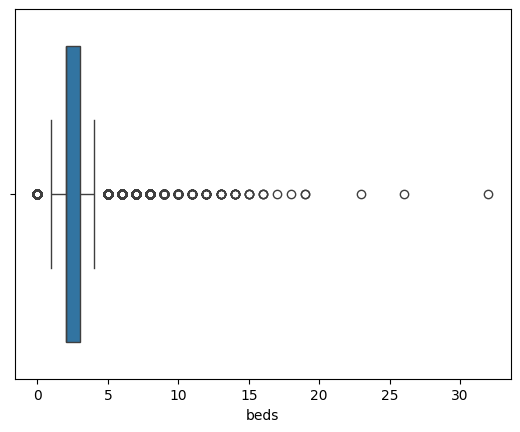

In [162]:
sns.boxplot(x=hawaii["beds"])
plt.show()

In [164]:
hawaii = hawaii[hawaii["bedrooms"] != 48]
hawaii = hawaii[hawaii["beds"] < 20]# Drop the outliers

In [166]:
hawaii.count() # 5 rows were dropped.

host_response_time        25272
host_identity_verified    25272
neighbourhood_cleansed    25272
room_type                 25272
accommodates              25272
bedrooms                  25272
beds                      25272
bathrooms                 25272
price                     25272
minimum_nights            25272
number_of_reviews         25272
number_of_reviews_ltm     25272
number_of_reviews_l30d    25272
review_scores_rating      25272
dtype: int64

In [167]:
hawaii.describe()

,host_response_time,host_identity_verified,accommodates,bedrooms,beds,bathrooms,price,minimum_nights,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,review_scores_rating
count,25272.000000,25272.000000,25272.000000,25272.000000,25272.000000,25272.000000,25272.000000,25272.000000,25272.000000,25272.000000,25272.000000,25272.000000
mean,1.196858,0.877770,4.697887,1.560739,2.572768,1.606818,493.947610,5.090100,52.966010,10.948916,0.749565,4.794730
std,0.510955,0.327558,2.313114,1.086223,1.513269,0.881427,2520.542265,13.167937,85.718855,14.875212,1.270723,0.318033
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,9.000000,1.000000,1.000000,0.000000,0.000000,1.000000
25%,1.000000,1.000000,4.000000,1.000000,2.000000,1.000000,149.000000,1.000000,5.000000,1.000000,0.000000,4.730000
50%,1.000000,1.000000,4.000000,1.000000,2.000000,1.000000,217.000000,2.000000,20.000000,5.000000,0.000000,4.890000
75%,1.000000,1.000000,6.000000,2.000000,3.000000,2.000000,350.000000,3.000000,64.000000,16.000000,1.000000,5.000000
max,4.000000,1.000000,16.000000,14.000000,19.000000,11.500000,50123.000000,365.000000,1506.000000,353.000000,29.000000,5.000000


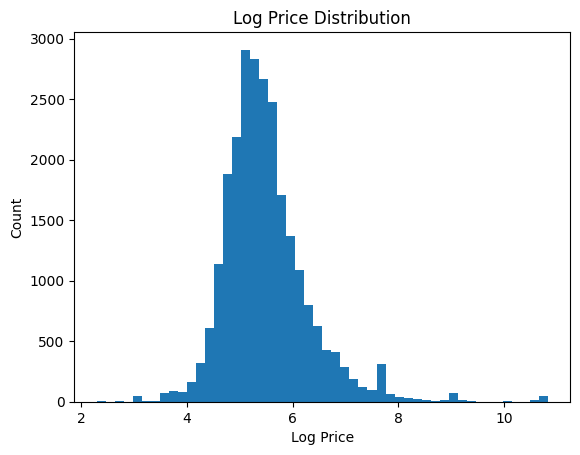

In [175]:
plt.hist(np.log1p(hawaii["price"]), bins=50)
plt.xlabel("Log Price")
plt.ylabel("Count")
plt.title("Log Price Distribution")
plt.show()

In [169]:
hawaii.bedrooms.median()

np.float64(1.0)

In [170]:
hawaii.beds.median()

np.float64(2.0)

In [171]:
hawaii.bathrooms.median()

np.float64(1.0)

In [176]:
hawaii.price.median()

np.float64(217.0)

Column Description

 0   host_response_time      : Most of the hosts response in an hour (mean: 1.19)
 
 1   host_identity_verified  : Most of the hosts verified their identity (mean: 0.88)
 
 2   neighbourhood_cleansed  : There are 30 neighbourhoods.   
 
 3   room_type               : There are 4 room types (['Entire home/apt', 'Private room', 'Shared room', 'Hotel room']).
 
 4   accommodates            : Maximum accommodates is 16, minimum accommodats is 1, and mean is 4.70.
 
 5   bedrooms                : Maximum bedrooms is 14, minimum bedrooms is 0, and median is 1.
 
 6   beds                    : Maximum beds is 19, minimum beds is 0, and median is 2.
 
 7   bathrooms               : Maximum bathrooms is 11.5, minimum bathrooms is 0, and median is 1.
 
 8   price                   : Maximum price is 50123, minumun 9, and median is 217.
 
 9   minimum_nights          : Max is 365, Min is 1.
 
 10  number_of_reviews       : Max is 1506, Min is 1.
 
 11  number_of_reviews_ltm   : Max is 353, Min is 0. 
 
 12  number_of_reviews_l30d  : Max is 29, Min is 0. 
 
 13  review_scores_rating    : Max is 5.0, Min is 1.0, and Mean is 4.79.

In [178]:
price = hawaii["price"] 

print("min price:", price.min())
print("num <= 0:", (price <= 0).sum())
print("num NaN:", price.isna().sum())
print("top 5 largest:", price.sort_values(ascending=False).head())

min price: 9.0
num <= 0: 0
num NaN: 0
top 5 largest: 25444    3199.0
18290    3196.0
18414    3196.0
18415    3196.0
3509     3181.0
Name: price, dtype: float64


In [179]:
p99 = hawaii["price"].quantile(0.99)
hawaii = hawaii[hawaii["price"] <= p99]
hawaii

,host_response_time,host_identity_verified,neighbourhood_cleansed,room_type,accommodates,bedrooms,beds,bathrooms,price,minimum_nights,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,review_scores_rating
0,1.0,1.0,South Kohala,Entire home/apt,2,1.0,1.0,1.0,136.0,3,45,7,0,4.80
1,1.0,1.0,South Kona,Entire home/apt,2,0.0,2.0,1.0,122.0,5,235,11,1,4.67
3,1.0,1.0,Kihei-Makena,Entire home/apt,4,1.0,2.0,2.0,150.0,4,96,14,0,4.71
4,1.0,0.0,North Shore Kauai,Entire home/apt,2,0.0,1.0,1.0,149.0,3,193,13,1,4.50
6,1.0,1.0,Puna,Entire home/apt,9,4.0,6.0,2.0,279.0,2,184,9,0,4.85
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33176,1.0,1.0,North Kona,Entire home/apt,8,3.0,4.0,2.0,416.0,2,1,1,1,5.00
33227,1.0,0.0,Primary Urban Center,Entire home/apt,4,1.0,2.0,1.0,124.0,1,1,1,1,5.00
33229,1.0,0.0,Primary Urban Center,Private room,5,1.0,3.0,1.0,147.0,1,1,1,1,5.00
33290,1.0,1.0,North Kona,Entire home/apt,6,2.0,2.0,1.0,238.0,2,2,2,2,5.00


y: price
x: room_type, minimum_night,  neighbourhood, neighbourhood_group

In [184]:
X = hawaii.drop(columns=["review_scores_rating"])
y = hawaii["review_scores_rating"]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [185]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [186]:
y_pred = rf.predict(X_test)

In [187]:
rmse = root_mean_squared_error(y_test, y_pred)
print("RMSE:", rmse)

RMSE: 0.31670569679577426


In [188]:
importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importance.head(15)

price                                          0.290258
number_of_reviews                              0.157008
number_of_reviews_ltm                          0.086002
minimum_nights                                 0.064642
accommodates                                   0.059857
beds                                           0.059360
bathrooms                                      0.046703
bedrooms                                       0.035199
host_response_time                             0.031399
neighbourhood_cleansed_Primary Urban Center    0.021761
number_of_reviews_l30d                         0.017205
host_identity_verified                         0.017091
neighbourhood_cleansed_North Kona              0.013641
room_type_Private room                         0.013131
neighbourhood_cleansed_Lahaina                 0.012789
dtype: float64

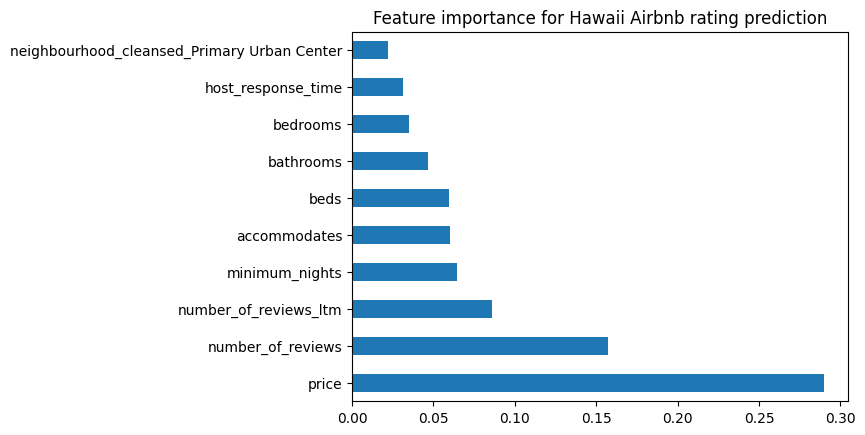

In [189]:
importance.head(10).plot(kind="barh")
plt.title("Feature importance for Hawaii Airbnb rating prediction")
plt.show()

In [193]:
# Feature Engineering: Pricing -> Relative Pricing
## Relative Pricing =  Pricing / Mean Pricing of listings with same neighborhood, # of bedrooms and bathrooms, and roomtype

group_cols = ["bedrooms", "bathrooms", "neighbourhood_cleansed", "room_type"]

hawaii["avg_price_group"] = hawaii.groupby(group_cols)["price"].transform("mean")

hawaii["relative_price"] = hawaii["price"] / hawaii["avg_price_group"]

X = hawaii.drop(columns=[
    "review_scores_rating",
    "price",
    "avg_price_group"
])
X["relative_price"] = hawaii["relative_price"]

y = hawaii["review_scores_rating"]

X = pd.get_dummies(X, drop_first=True)

# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# model
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# train
rf.fit(X_train, y_train)

# prediction
y_pred = rf.predict(X_test)

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(20)

relative_price                                 0.309614
number_of_reviews                              0.151834
number_of_reviews_ltm                          0.085447
minimum_nights                                 0.063360
beds                                           0.058041
accommodates                                   0.055809
bathrooms                                      0.047020
bedrooms                                       0.034841
host_response_time                             0.030350
neighbourhood_cleansed_Primary Urban Center    0.021352
number_of_reviews_l30d                         0.017524
host_identity_verified                         0.017178
room_type_Private room                         0.012270
neighbourhood_cleansed_North Kona              0.011927
neighbourhood_cleansed_Lahaina                 0.009842
neighbourhood_cleansed_Kihei-Makena            0.009547
neighbourhood_cleansed_North Shore Kauai       0.009072
neighbourhood_cleansed_Lihue                   0

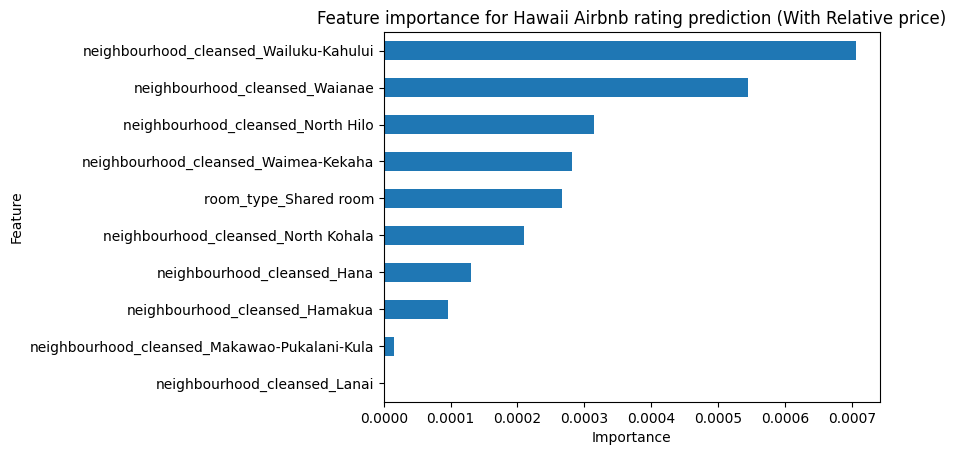

In [194]:
importance.sort_values(ascending=True).head(10).plot(kind="barh")

plt.title("Feature importance for Hawaii Airbnb rating prediction (With Relative price)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()